# 04 - Transfer Learning

Compare three pretrained backbones (ResNet50, DenseNet121, EfficientNetB0) against the custom CNN baseline from `03_Model_Training.ipynb`, using a two-stage transfer learning approach: train a new classification head with the frozen pretrained base, then fine-tune the top layers of the base at a low learning rate.

## Workflow

1. Load `data/processed/Training` and `data/processed/Testing`.
2. For each architecture: build the model with the correct architecture-specific preprocessing, train the head with the base frozen (Stage 1), then unfreeze the top layers and fine-tune at a low learning rate (Stage 2).
3. Compare test accuracy across all three architectures.
4. Evaluate the best-performing model in detail: confusion matrix, classification report.
5. Save the best model for use in `05_GradCAM.ipynb`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Create the target directory if it doesn't exist
!mkdir -p /content/data/raw/

# Unzip your data into the /content/data/raw/ directory
# Assuming 'raw_data.zip' is in your Google Drive's root. Adjust path if necessary.
!unzip -q "/content/drive/MyDrive/raw_data.zip" -d /content/data/raw/

print("Data unzipped to /content/data/raw/")

Data unzipped to /content/data/raw/


In [3]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0
from tensorflow.keras.applications import resnet50, densenet, efficientnet
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)
assert len(gpus) > 0, (
    'No GPU detected. In Colab: Runtime > Change runtime type > T4 GPU. '
    'Training three architectures on CPU will be extremely slow.'
)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from __future__ import annotations
import os
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    # Adjust this to match your actual cloned repo folder name in Colab
    PROJECT_ROOT = Path('/content/') # Corrected to point to /content where data was unzipped
    # Save models/outputs to Drive so they survive runtime disconnects
    MODELS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/models')
    OUTPUTS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/outputs')
else:
    def find_project_root(start: Path | None = None) -> Path:
        start = start or Path.cwd()
        for candidate in [start, *start.parents]:
            if (candidate / 'data' / 'raw' / 'Training').exists() and (candidate / 'data' / 'raw' / 'Testing').exists():
                return candidate
        raise FileNotFoundError('Could not locate data/raw/Training and data/raw/Testing.')

    PROJECT_ROOT = find_project_root()
    MODELS_DIR = PROJECT_ROOT / 'models'
    OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' # Re-added definition
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' # Re-added definition
AUGMENTED_DIR = PROJECT_ROOT / 'data' / 'augmented' # Re-added definition

TRAIN_DIR = RAW_DIR / 'Training' # Changed to use RAW_DIR
TEST_DIR = RAW_DIR / 'Testing' # Changed to use RAW_DIR
TRANSFER_MODELS_DIR = MODELS_DIR / 'transfer_learning' # Keep this as it was in original notebook
CM_DIR = OUTPUTS_DIR / 'confusion_matrix'
GRAPH_DIR = OUTPUTS_DIR / 'graphs'
REPORT_DIR = OUTPUTS_DIR / 'reports'
for folder in [MODELS_DIR, TRANSFER_MODELS_DIR, CM_DIR, GRAPH_DIR, REPORT_DIR]: # Added TRANSFER_MODELS_DIR here as it's defined
    folder.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.15

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Re-added definition
TARGET_SIZE = (224, 224) # Re-added definition
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'} # Re-added definition

assert TRAIN_DIR.exists() and TEST_DIR.exists(), (
    f"Data not found at {TRAIN_DIR} / {TEST_DIR}. "
    "If in Colab, check your Drive mount and unzip path; if local, check PROJECT_ROOT detection."
)

IN_COLAB, PROJECT_ROOT, TRAIN_DIR, TEST_DIR, RAW_DIR, PROCESSED_DIR, AUGMENTED_DIR, TARGET_SIZE

(True,
 PosixPath('/content'),
 PosixPath('/content/data/raw/Training'),
 PosixPath('/content/data/raw/Testing'),
 PosixPath('/content/data/raw'),
 PosixPath('/content/data/processed'),
 PosixPath('/content/data/augmented'),
 (224, 224))

In [6]:
train_all_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,  # must match train call's shuffle+seed for a correct complementary split
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

class_names = train_all_ds.class_names
num_classes = len(class_names)

train_ds = train_all_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

class_names, num_classes

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.


(['glioma', 'meningioma', 'notumor', 'pituitary'], 4)

## Augmentation

Note: unlike `03_Model_Training.ipynb`, there is no `Rescaling(1./255)` layer here. Each pretrained backbone has its own required input normalization (applied via `preprocess_input` below), so the raw 0-255 images from `image_dataset_from_directory` are augmented first, then normalized per-architecture inside `build_transfer_model`.

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10, value_range=(0, 255)),  # raw 0-255 range here, no Rescaling before this
], name='augmentation')

## Model Builder

Each architecture expects a different input normalization, matching what it saw during ImageNet pretraining:

- **ResNet50**: `resnet50.preprocess_input` — converts RGB to BGR and subtracts ImageNet channel means (no 0-1 scaling).
- **DenseNet121**: `densenet.preprocess_input` — scales to 0-1, then normalizes using ImageNet mean/std.
- **EfficientNetB0**: `efficientnet.preprocess_input` — effectively a no-op; normalization is built into the model itself.

Using the wrong preprocessing function for a given architecture is a common silent bug — the model will still train, just far less effectively, since the pretrained weights expect a specific input distribution.

In [8]:
MODEL_CONFIGS = {
    'resnet50': {
        'base_class': ResNet50,
        'preprocess_fn': resnet50.preprocess_input,
    },
    'densenet121': {
        'base_class': DenseNet121,
        'preprocess_fn': densenet.preprocess_input,
    },
    'efficientnetb0': {
        'base_class': EfficientNetB0,
        'preprocess_fn': efficientnet.preprocess_input,
    },
}

def build_transfer_model(model_key):
    config = MODEL_CONFIGS[model_key]
    base_model = config['base_class'](
        include_top=False,
        weights='imagenet',
        input_shape=IMG_SIZE + (3,),
    )
    base_model.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = config['preprocess_fn'](x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_key)
    return model, base_model

## Two-Stage Training

**Stage 1**: freeze the pretrained base entirely, train only the new classification head at a normal learning rate (1e-3). This lets the head adapt to the new task quickly without disturbing the pretrained features.

**Stage 2**: unfreeze the top N layers of the base model and fine-tune the whole thing at a much lower learning rate (1e-5), so the pretrained weights adjust gently to MRI-specific features without being destroyed by large gradient updates.

In [9]:
def train_transfer_model(model_key, frozen_epochs=10, fine_tune_epochs=10, fine_tune_layers=30):
    print(f'\n{"="*60}\nTraining {model_key}\n{"="*60}')
    model, base_model = build_transfer_model(model_key)
    checkpoint_path = TRANSFER_MODELS_DIR / f'{model_key}_best.keras'

    # Stage 1: train the classification head with the base frozen
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    stage1_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, min_delta=1e-3,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1,
        ),
    ]

    print('-- Stage 1: training classification head (base frozen) --')
    history_stage1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=frozen_epochs,
        callbacks=stage1_callbacks,
    )

    # Stage 2: unfreeze the top layers of the base model and fine-tune at a low learning rate
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    stage2_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, min_delta=1e-3,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor='val_loss', save_best_only=True, verbose=1,
        ),
    ]

    print(f'-- Stage 2: fine-tuning top {fine_tune_layers} layers --')
    history_stage2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=fine_tune_epochs,
        callbacks=stage2_callbacks,
    )

    combined_history = {}
    for key in history_stage1.history:
        combined_history[key] = history_stage1.history[key] + history_stage2.history.get(key, [])

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f'{model_key} test accuracy: {test_accuracy:.4f}, test loss: {test_loss:.4f}')

    model.save(TRANSFER_MODELS_DIR / f'{model_key}_final.keras')

    return {
        'model': model,
        'history': combined_history,
        'stage1_epochs': len(history_stage1.history['loss']),
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
    }

## Run All Three Architectures

This trains ResNet50, DenseNet121, and EfficientNetB0 in sequence. On a Colab T4 GPU, expect roughly 20-40 minutes total depending on how quickly EarlyStopping triggers for each. Results are kept in memory in the `results` dict for comparison below.

In [10]:
results = {}
for model_key in MODEL_CONFIGS:
    results[model_key] = train_transfer_model(model_key)


Training resnet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
-- Stage 1: training classification head (base frozen) --
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 43s 192ms/step - accuracy: 0.7101 - loss: 0.7826 - val_accuracy: 0.8452 - val_loss: 0.4328 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 23s 154ms/step - accuracy: 0.8109 - loss: 0.5225 - val_accuracy: 0.8405 - val_loss: 0.4154 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.8202 - loss: 0.4845 - val_accuracy: 0.8714 - val_loss: 0.3556 - learning_rate: 0.0010
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.8359 - loss: 0.4530 - val_accuracy: 0.8750 - val_loss: 0.3472 - learning_rate: 0.0010
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.8468 - loss: 0.4234 - val_accuracy: 0.8833 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.8437 - loss: 0.4213 - val_ac

In [11]:
comparison_df = pd.DataFrame({
    'model': list(results.keys()),
    'test_accuracy': [results[k]['test_accuracy'] for k in results],
    'test_loss': [results[k]['test_loss'] for k in results],
})
comparison_df = comparison_df.sort_values('test_accuracy', ascending=False).reset_index(drop=True)
comparison_df

,model,test_accuracy,test_loss
0,resnet50,0.906875,0.450393
1,densenet121,0.818750,0.518630
2,efficientnetb0,0.800625,0.588206


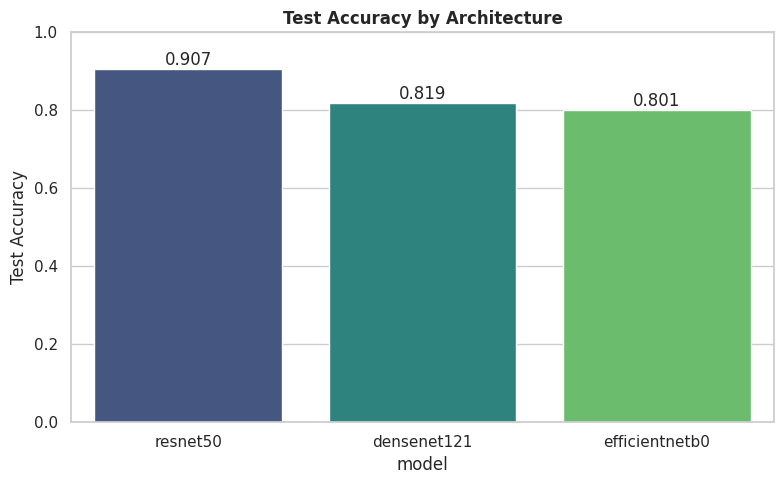

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comparison_df, x='model', y='test_accuracy', hue='model', legend=False, palette='viridis', ax=ax)
ax.set_title('Test Accuracy by Architecture')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 1)
for index, row in comparison_df.iterrows():
    ax.text(index, row['test_accuracy'] + 0.01, f"{row['test_accuracy']:.3f}", ha='center')
plt.tight_layout()
plt.savefig(GRAPH_DIR / 'transfer_learning_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

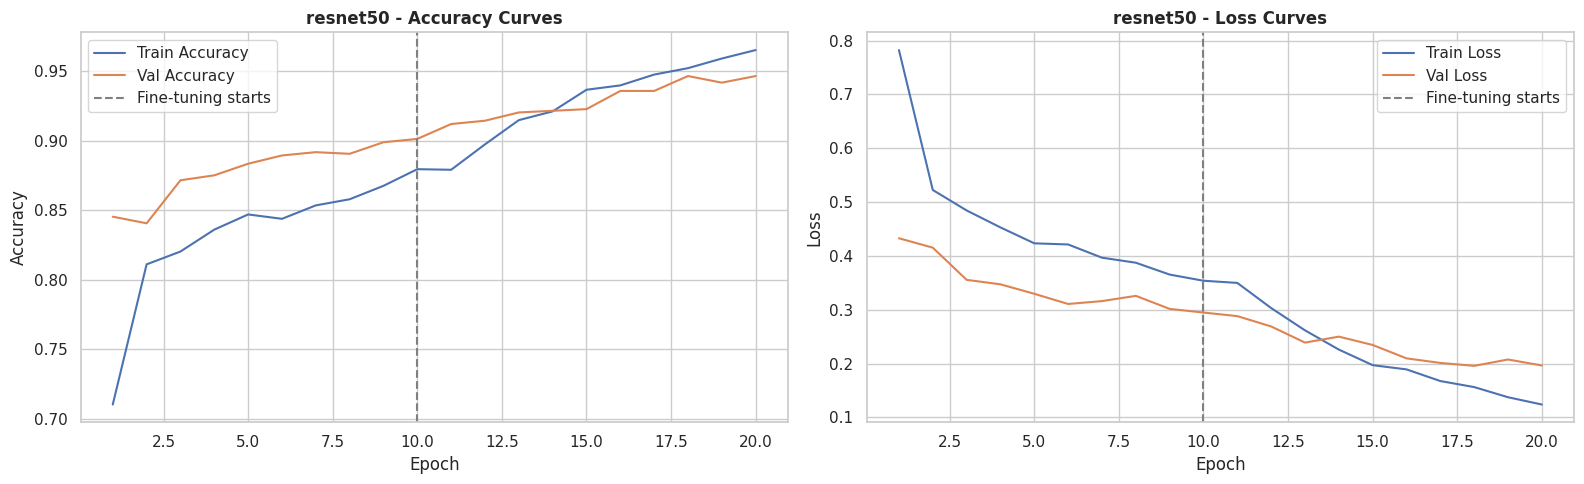

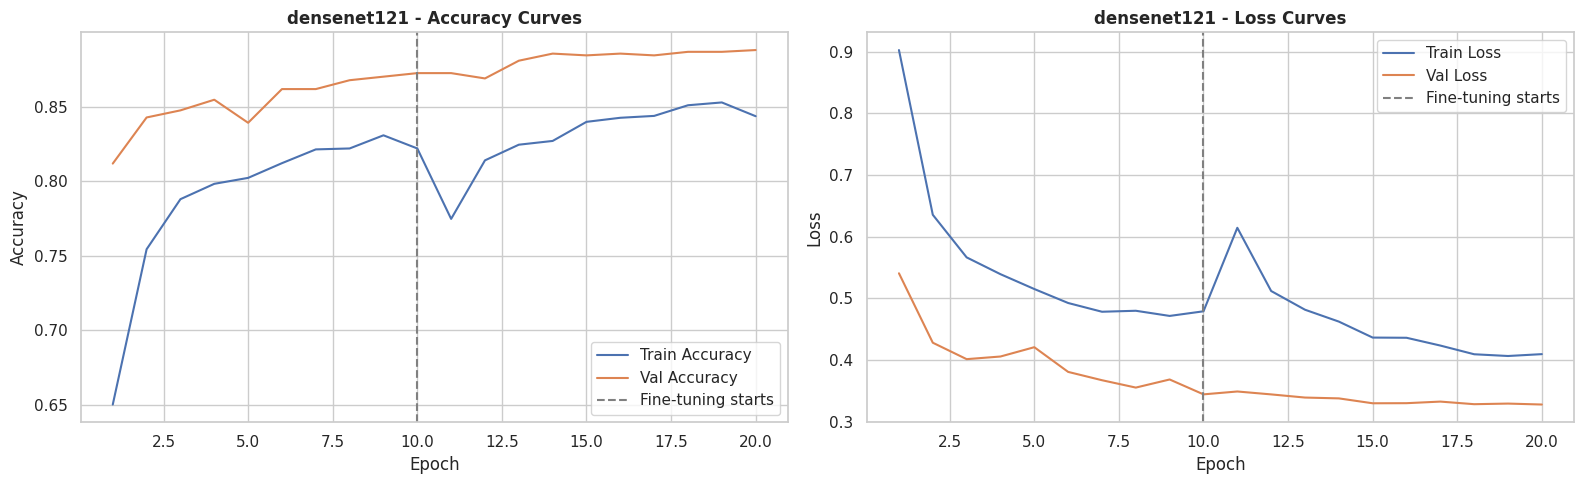

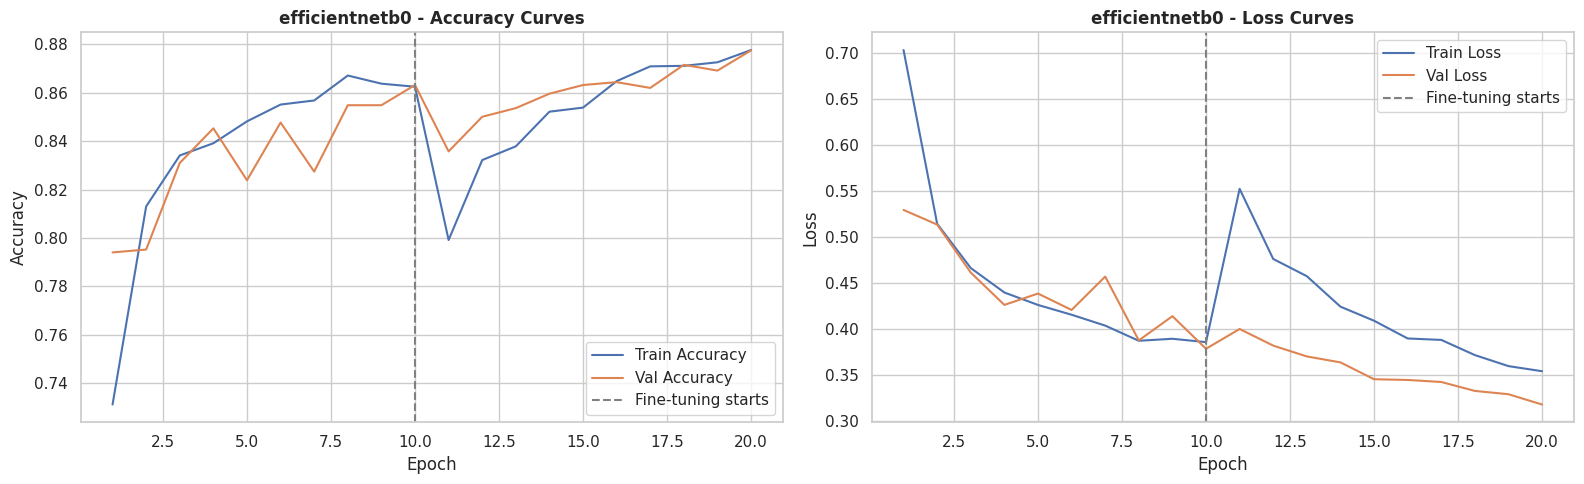

In [13]:
for model_key, result in results.items():
    history_dict = result['history']
    epochs_range = range(1, len(history_dict['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(epochs_range, history_dict['accuracy'], label='Train Accuracy')
    axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Val Accuracy')
    axes[0].axvline(result['stage1_epochs'], color='gray', linestyle='--', label='Fine-tuning starts')
    axes[0].set_title(f'{model_key} - Accuracy Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epochs_range, history_dict['loss'], label='Train Loss')
    axes[1].plot(epochs_range, history_dict['val_loss'], label='Val Loss')
    axes[1].axvline(result['stage1_epochs'], color='gray', linestyle='--', label='Fine-tuning starts')
    axes[1].set_title(f'{model_key} - Loss Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(GRAPH_DIR / f'{model_key}_training_curves.png', dpi=200, bbox_inches='tight')
    plt.show()

## Detailed Evaluation of the Best Model

Best performing architecture: resnet50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step
              precision    recall  f1-score   support

      glioma     0.9659    0.7800    0.8631       400
  meningioma     0.8378    0.8650    0.8512       400
     notumor     0.9387    0.9950    0.9660       400
   pituitary     0.8977    0.9875    0.9405       400

    accuracy                         0.9069      1600
   macro avg     0.9100    0.9069    0.9052      1600
weighted avg     0.9100    0.9069    0.9052      1600



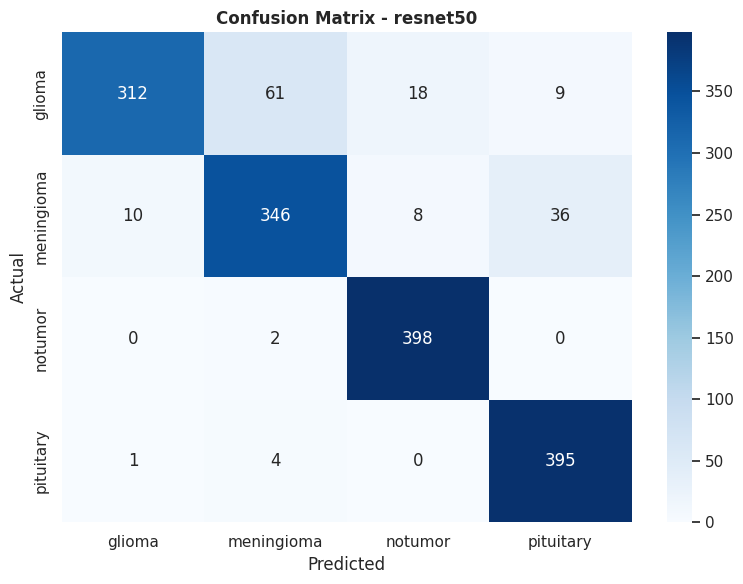

Saved best model to /content/drive/MyDrive/brain_tumor_capstone/models/best_transfer_model.keras


In [14]:
best_model_key = comparison_df.iloc[0]['model']
best_model = results[best_model_key]['model']
print(f'Best performing architecture: {best_model_key}')

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_key}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(CM_DIR / f'{best_model_key}_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

with open(REPORT_DIR / f'{best_model_key}_classification_report.txt', 'w') as report_file:
    report_file.write(report)

best_model.save(MODELS_DIR / 'best_transfer_model.keras')
print(f'Saved best model to {MODELS_DIR / "best_transfer_model.keras"}')

## Grad-CAM Prep

Grad-CAM needs the name of the last convolutional layer in the base model. Each architecture names it differently, so this prints the last few layers of the winning backbone for reference in `05_GradCAM.ipynb`.

In [17]:
best_model_key = comparison_df.iloc[0]['model']
best_model = results[best_model_key]['model']
print(f'Best performing architecture: {best_model_key}')

# Find the actual pretrained base model (e.g., ResNet50, DenseNet121, EfficientNetB0)
# within the layers of the combined 'best_model'.
# These base models typically have names matching their architecture, e.g., 'resnet50'.
base_model_found = None
for layer in best_model.layers:
    if layer.name == best_model_key:
        base_model_found = layer
        break

if base_model_found is None:
    raise ValueError(f"Could not find the base model '{best_model_key}' within the best_model's layers.")

print(f'Base model: {base_model_found.name}')
print('Last 5 layers (candidates for the Grad-CAM target layer):')
for layer in base_model_found.layers[-5:]:
    # Correctly access the shape of the layer's output tensor
    print(f'  {layer.name:30s} {layer.output.shape}')

Best performing architecture: resnet50
Base model: resnet50
Last 5 layers (candidates for the Grad-CAM target layer):
  conv5_block3_2_relu            (None, 7, 7, 512)
  conv5_block3_3_conv            (None, 7, 7, 2048)
  conv5_block3_3_bn              (None, 7, 7, 2048)
  conv5_block3_add               (None, 7, 7, 2048)
  conv5_block3_out               (None, 7, 7, 2048)
